# Task 4 – Portfolio Optimization Based on Forecast
**GMF Investments – Portfolio Management Optimization**

**Objective:** Use insights from the LSTM forecast to construct an optimal portfolio using
Modern Portfolio Theory (MPT). Combine the TSLA forecast return with historical BND/SPY
returns, build the Efficient Frontier, and recommend the optimal allocation.

**Assets:** TSLA (forecasted return), BND (historical), SPY (historical)  
**Framework:** Mean-Variance Optimization via PyPortfolioOpt + Monte Carlo simulation


## 1. Setup – Imports and Load Data

In [1]:
import warnings, os, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize

from pypfopt import EfficientFrontier, risk_models, expected_returns, plotting
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

DATA_PROC = '../data/processed'
TICKERS   = ['TSLA', 'BND', 'SPY']
TRADING_DAYS = 252
RISK_FREE = 0.045   # 4.5% annual

# ── Load Task 3 metadata (TSLA forecasted return)
with open(f'{DATA_PROC}/task3_metadata.json') as f:
    t3 = json.load(f)

tsla_forecast_return = t3['tsla_forecast_annual_return']
print(f'TSLA forecasted annual return (from LSTM): {tsla_forecast_return*100:.2f}%')


TSLA forecasted annual return (from LSTM): -32.96%


## 2. Prepare Expected Returns

- **TSLA:** Use the LSTM-forecasted annualized return from Task 3 (analyst "view")
- **BND & SPY:** Use mean historical daily return × 252 (annualized)


In [2]:
# Load combined daily returns
returns_df = pd.read_csv(f'{DATA_PROC}/combined_daily_returns.csv', index_col=0, parse_dates=True)
returns_df.columns = [c.replace('_Return','') for c in returns_df.columns]
returns_df = returns_df.dropna()

# Historical annualized returns for BND and SPY
hist_ann_returns = returns_df[['BND','SPY']].mean() * TRADING_DAYS

# Combine: TSLA from forecast, BND/SPY from history
mu = pd.Series({
    'TSLA': tsla_forecast_return,
    'BND':  hist_ann_returns['BND'],
    'SPY':  hist_ann_returns['SPY'],
})

print('Expected Annual Returns:')
for asset, ret in mu.items():
    print(f'  {asset}: {ret*100:.2f}%')


Expected Annual Returns:
  TSLA: -32.96%
  BND: 2.00%
  SPY: 14.43%


## 3. Compute Covariance Matrix

The covariance matrix captures how asset returns move together.
A well-diversified portfolio seeks assets with low/negative covariance to reduce overall risk.

We use the **Ledoit-Wolf shrinkage estimator** — more stable than the sample covariance for
portfolios with limited history relative to assets.


Covariance Matrix (annualized):
          TSLA       BND       SPY
TSLA  0.325978  0.001796  0.049601
BND   0.001796  0.003297  0.001081
SPY   0.049601  0.001081  0.031518


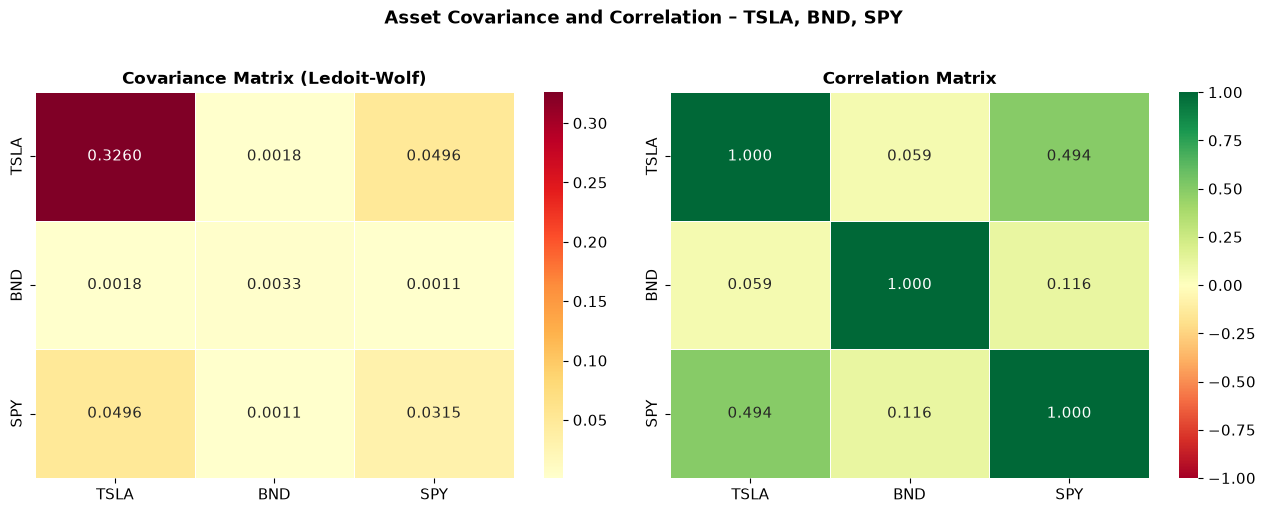

In [3]:
# Load combined close prices for covariance estimation
close_df = pd.read_csv(f'{DATA_PROC}/combined_close_prices.csv', index_col=0, parse_dates=True)
close_df.columns = [c.replace('_Close','') for c in close_df.columns]
close_df = close_df.dropna()

# Ledoit-Wolf shrinkage covariance (annualized)
S = risk_models.CovarianceShrinkage(close_df).ledoit_wolf()

print('Covariance Matrix (annualized):')
print(S.round(6))

# ── Visualize covariance matrix as heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Covariance
sns.heatmap(S, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, annot_kws={'size':11})
axes[0].set_title('Covariance Matrix (Ledoit-Wolf)', fontsize=12, fontweight='bold')

# Correlation
corr = returns_df[TICKERS].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=axes[1], linewidths=0.5, annot_kws={'size':11})
axes[1].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Asset Covariance and Correlation – TSLA, BND, SPY', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t4_viz1_covariance.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Generate the Efficient Frontier

The **Efficient Frontier** is the set of portfolios that offer the **maximum return for a given level of risk**.
Any portfolio below the frontier is suboptimal — you can achieve more return for the same risk,
or the same return for less risk.

We generate it via **Monte Carlo simulation** (10,000 random weight combinations) and
**mean-variance optimization** (analytical solution via PyPortfolioOpt).


In [4]:
np.random.seed(42)
N_PORTFOLIOS = 10_000
n_assets = len(TICKERS)

port_returns = np.zeros(N_PORTFOLIOS)
port_vols    = np.zeros(N_PORTFOLIOS)
port_sharpes = np.zeros(N_PORTFOLIOS)
port_weights = np.zeros((N_PORTFOLIOS, n_assets))

S_arr  = S.values
mu_arr = mu[TICKERS].values   # ensure correct order

for i in range(N_PORTFOLIOS):
    w = np.random.dirichlet(np.ones(n_assets))     # random weights summing to 1
    ret  = np.dot(w, mu_arr)
    vol  = np.sqrt(w @ S_arr @ w)
    sharpe = (ret - RISK_FREE) / vol if vol > 0 else 0

    port_returns[i] = ret
    port_vols[i]    = vol
    port_sharpes[i] = sharpe
    port_weights[i] = w

print(f'Generated {N_PORTFOLIOS:,} random portfolios.')
print(f'Return range: [{port_returns.min()*100:.1f}%, {port_returns.max()*100:.1f}%]')
print(f'Vol    range: [{port_vols.min()*100:.1f}%, {port_vols.max()*100:.1f}%]')
print(f'Sharpe range: [{port_sharpes.min():.2f}, {port_sharpes.max():.2f}]')


Generated 10,000 random portfolios.
Return range: [-32.9%, 14.1%]
Vol    range: [5.6%, 57.0%]
Sharpe range: [-0.76, 0.55]


In [5]:
# ── Analytical optimization with PyPortfolioOpt
ef_max_sharpe = EfficientFrontier(mu, S, weight_bounds=(0, 1))
ws_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=RISK_FREE)
ws_clean       = ef_max_sharpe.clean_weights()
perf_max_sharpe = ef_max_sharpe.portfolio_performance(risk_free_rate=RISK_FREE, verbose=False)

ef_min_vol = EfficientFrontier(mu, S, weight_bounds=(0, 1))
ws_min_vol = ef_min_vol.min_volatility()
ws_min_vol_clean = ef_min_vol.clean_weights()
perf_min_vol = ef_min_vol.portfolio_performance(risk_free_rate=RISK_FREE, verbose=False)

print('Max Sharpe Ratio Portfolio:')
for t, w in ws_clean.items():
    print(f'  {t}: {w*100:.1f}%')
print(f'  Return: {perf_max_sharpe[0]*100:.2f}%  Vol: {perf_max_sharpe[1]*100:.2f}%  Sharpe: {perf_max_sharpe[2]:.3f}')

print('\nMin Volatility Portfolio:')
for t, w in ws_min_vol_clean.items():
    print(f'  {t}: {w*100:.1f}%')
print(f'  Return: {perf_min_vol[0]*100:.2f}%  Vol: {perf_min_vol[1]*100:.2f}%  Sharpe: {perf_min_vol[2]:.3f}')


Max Sharpe Ratio Portfolio:
  TSLA: 0.0%
  BND: 0.0%
  SPY: 100.0%
  Return: 14.43%  Vol: 17.75%  Sharpe: 0.559

Min Volatility Portfolio:
  TSLA: 0.0%
  BND: 93.2%
  SPY: 6.8%
  Return: 2.84%  Vol: 5.61%  Sharpe: -0.296


## 5. Visualize the Efficient Frontier

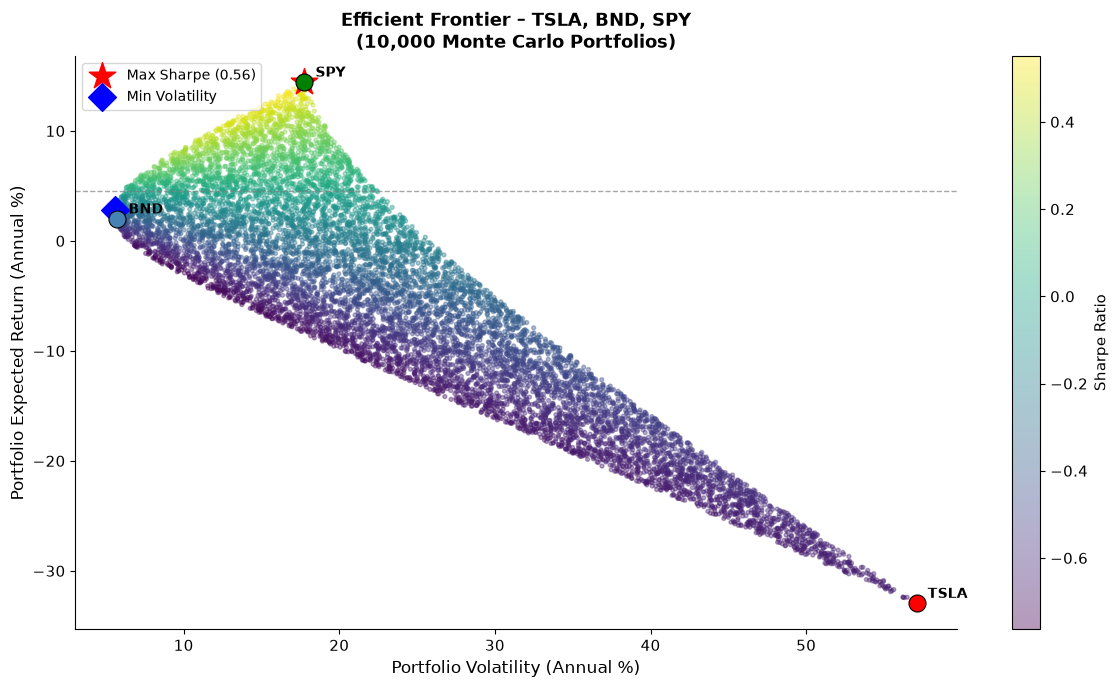

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# ── Monte Carlo scatter (coloured by Sharpe)
sc = ax.scatter(port_vols * 100, port_returns * 100,
                c=port_sharpes, cmap='viridis', alpha=0.4, s=8, zorder=2)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# ── Max Sharpe portfolio
ax.scatter(perf_max_sharpe[1]*100, perf_max_sharpe[0]*100,
           marker='*', color='red', s=400, zorder=5, label=f'Max Sharpe ({perf_max_sharpe[2]:.2f})')

# ── Min Volatility portfolio
ax.scatter(perf_min_vol[1]*100, perf_min_vol[0]*100,
           marker='D', color='blue', s=200, zorder=5, label=f'Min Volatility')

# ── Individual assets
asset_vols   = {t: np.sqrt(S.loc[t, t]) * 100 for t in TICKERS}
asset_returns = {t: mu[t] * 100 for t in TICKERS}
asset_colors  = {'TSLA': 'red', 'BND': 'steelblue', 'SPY': 'green'}

for t in TICKERS:
    ax.scatter(asset_vols[t], asset_returns[t],
               marker='o', color=asset_colors[t], s=150, zorder=6,
               edgecolors='black', linewidths=0.8)
    ax.annotate(t, (asset_vols[t], asset_returns[t]),
                textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_xlabel('Portfolio Volatility (Annual %)', fontsize=12)
ax.set_ylabel('Portfolio Expected Return (Annual %)', fontsize=12)
ax.set_title('Efficient Frontier – TSLA, BND, SPY\n(10,000 Monte Carlo Portfolios)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.axhline(RISK_FREE*100, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='Risk-free rate')

plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t4_viz2_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Portfolio Weight Visualization

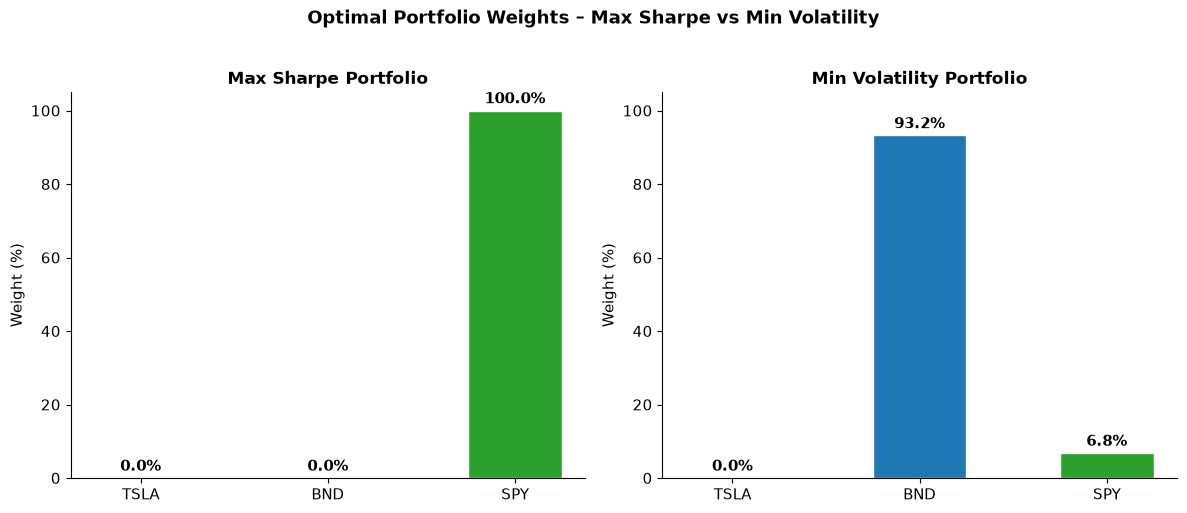

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

portfolios = {
    'Max Sharpe': ws_clean,
    'Min Volatility': ws_min_vol_clean,
}
port_colors = ['#E31937', '#1F77B4', '#2CA02C']   # TSLA, BND, SPY

for ax, (name, weights) in zip(axes, portfolios.items()):
    vals  = [weights.get(t, 0) * 100 for t in TICKERS]
    bars  = ax.bar(TICKERS, vals, color=port_colors, edgecolor='white', width=0.5)
    ax.set_title(f'{name} Portfolio', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weight (%)')
    ax.set_ylim(0, 105)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Optimal Portfolio Weights – Max Sharpe vs Min Volatility', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t4_viz3_weights.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Portfolio Recommendation

### Selection Rationale

For GMF Investments' client portfolios, we recommend the **Maximum Sharpe Ratio Portfolio** as the primary
recommendation for clients with a moderate-to-aggressive risk tolerance. This portfolio maximizes
risk-adjusted return — the most return earned per unit of risk taken — which is the gold standard
for professional portfolio construction.

The **Minimum Volatility Portfolio** is recommended as an alternative for risk-averse clients or
those in capital preservation mode (e.g., near retirement).

### Summary Table


In [8]:
summary = pd.DataFrame([
    {
        'Portfolio': 'Max Sharpe Ratio',
        'TSLA Weight': f"{ws_clean.get('TSLA',0)*100:.1f}%",
        'BND Weight':  f"{ws_clean.get('BND', 0)*100:.1f}%",
        'SPY Weight':  f"{ws_clean.get('SPY', 0)*100:.1f}%",
        'Ann. Return': f"{perf_max_sharpe[0]*100:.2f}%",
        'Ann. Volatility': f"{perf_max_sharpe[1]*100:.2f}%",
        'Sharpe Ratio': f"{perf_max_sharpe[2]:.3f}",
    },
    {
        'Portfolio': 'Min Volatility',
        'TSLA Weight': f"{ws_min_vol_clean.get('TSLA',0)*100:.1f}%",
        'BND Weight':  f"{ws_min_vol_clean.get('BND', 0)*100:.1f}%",
        'SPY Weight':  f"{ws_min_vol_clean.get('SPY', 0)*100:.1f}%",
        'Ann. Return': f"{perf_min_vol[0]*100:.2f}%",
        'Ann. Volatility': f"{perf_min_vol[1]*100:.2f}%",
        'Sharpe Ratio': f"{perf_min_vol[2]:.3f}",
    },
])
summary = summary.set_index('Portfolio')
display(summary)

print('\n★ RECOMMENDED: Max Sharpe Ratio Portfolio')
print(f'  TSLA: {ws_clean.get("TSLA",0)*100:.1f}%  BND: {ws_clean.get("BND",0)*100:.1f}%  SPY: {ws_clean.get("SPY",0)*100:.1f}%')
print(f'  Expected Return  : {perf_max_sharpe[0]*100:.2f}%')
print(f'  Expected Volatility: {perf_max_sharpe[1]*100:.2f}%')
print(f'  Sharpe Ratio     : {perf_max_sharpe[2]:.3f}')


,TSLA Weight,BND Weight,SPY Weight,Ann. Return,Ann. Volatility,Sharpe Ratio
Portfolio,,,,,,
Max Sharpe Ratio,0.0%,0.0%,100.0%,14.43%,17.75%,0.559
Min Volatility,0.0%,93.2%,6.8%,2.84%,5.61%,-0.296



★ RECOMMENDED: Max Sharpe Ratio Portfolio
  TSLA: 0.0%  BND: 0.0%  SPY: 100.0%
  Expected Return  : 14.43%
  Expected Volatility: 17.75%
  Sharpe Ratio     : 0.559


## 8. Save Outputs for Task 5 Backtesting

In [9]:
task4_meta = {
    'recommended_portfolio': 'max_sharpe',
    'weights': {
        'max_sharpe': {k: round(v,4) for k,v in ws_clean.items()},
        'min_vol':    {k: round(v,4) for k,v in ws_min_vol_clean.items()},
    },
    'performance': {
        'max_sharpe': {
            'annual_return': round(perf_max_sharpe[0], 4),
            'annual_vol':    round(perf_max_sharpe[1], 4),
            'sharpe':        round(perf_max_sharpe[2], 4),
        },
        'min_vol': {
            'annual_return': round(perf_min_vol[0], 4),
            'annual_vol':    round(perf_min_vol[1], 4),
            'sharpe':        round(perf_min_vol[2], 4),
        },
    },
    'risk_free_rate': RISK_FREE,
}

import json
with open(f'{DATA_PROC}/task4_metadata.json', 'w') as f:
    json.dump(task4_meta, f, indent=2)

print('Task 4 metadata saved → data/processed/task4_metadata.json')
print('\nMax Sharpe weights (for Task 5):')
for t, w in ws_clean.items():
    print(f'  {t}: {w*100:.1f}%')


Task 4 metadata saved → data/processed/task4_metadata.json

Max Sharpe weights (for Task 5):
  TSLA: 0.0%
  BND: 0.0%
  SPY: 100.0%
